# FIE — Reasoning Failure Detection: Benchmark Evaluation

**Failure Intelligence Engine (FIE)** — Step-level reasoning verification evaluated on:

| Dataset | Size | Domain | Access |
|---------|------|--------|---------|
| **GSM8K** | 1,319 | Grade-school math (arithmetic chains) | Public |
| **MATH-500** | 500 | Competition math (multi-step LaTeX) | Public |
| **TruthfulQA** | 817 | Factual accuracy / hallucination | Public |
| **GPQA** | 448 | Graduate-level STEM (expert-written) | Gated (HF login) |

**Modes evaluated:**
- `offline` — Pure Python AST eval, no API calls, ~1ms per case
- `groq` — Full pipeline: Groq decomposition + Wikidata/Serper factual + Socratic probing

All figures saved to `notebooks/benchmark_figures/`

In [1]:
# ── 0. Environment setup ───────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root

import json
import time
import warnings
from pathlib import Path
from datetime import datetime

# Load API keys from .env (GROQ_API_KEY, OPENAI_API_KEY, etc.)
from dotenv import load_dotenv
load_dotenv(dotenv_path=Path("../.env"), override=False)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator, PercentFormatter

warnings.filterwarnings('ignore')

# Output folder
FIG_DIR = Path("benchmark_figures")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("benchmark_results")
RES_DIR.mkdir(exist_ok=True)

print(f"Python  : {sys.version.split()[0]}")
print(f"Figures : {FIG_DIR.resolve()}")
print(f"Results : {RES_DIR.resolve()}")

Python  : 3.10.19
Figures : C:\Users\ASUS\Desktop\Failure_Intelligence_System\notebooks\benchmark_figures
Results : C:\Users\ASUS\Desktop\Failure_Intelligence_System\notebooks\benchmark_results


In [2]:
# ── 1. Research-grade colour palette & matplotlib style ────────────────────────
#
# Palette: Wong (2011) Nature Methods — the canonical colorblind-safe set
# used by Nature, Science, Cell, and most top ML venues.
# Reference: Bang Wong, "Points of view: Color coding", Nature Methods 8, 441 (2011)

WONG = {
    'black'    : '#000000',
    'orange'   : '#E69F00',
    'sky'      : '#56B4E9',
    'green'    : '#009E73',
    'yellow'   : '#F0E442',
    'blue'     : '#0072B2',
    'vermilion': '#D55E00',
    'purple'   : '#CC79A7',
}

# Semantic role → colour mapping for the paper
C = {
    'offline' : WONG['blue'],       # offline heuristic = cool blue
    'groq'    : WONG['orange'],     # online Groq       = warm orange
    'gsm8k'   : WONG['blue'],
    'math'    : WONG['sky'],
    'truthfulqa': WONG['green'],
    'gpqa'    : WONG['vermilion'],
    'recall'  : WONG['blue'],
    'precision': WONG['vermilion'],
    'f1'      : WONG['green'],
    'fpr'     : WONG['orange'],
    'arithmetic': WONG['blue'],
    'factual'  : WONG['vermilion'],
    'logical'  : WONG['green'],
    'socratic' : WONG['purple'],
    'tp'       : WONG['green'],
    'fp'       : WONG['vermilion'],
    'fn'       : WONG['orange'],
    'tn'       : WONG['sky'],
}

# Matplotlib rc — matches Nature/NeurIPS submission style
plt.rcParams.update({
    # Font
    'font.family'        : 'DejaVu Sans',
    'font.size'          : 9,
    'axes.titlesize'     : 10,
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 8,
    'legend.title_fontsize': 8,
    # Lines & markers
    'lines.linewidth'    : 1.5,
    'lines.markersize'   : 5,
    'patch.linewidth'    : 0.8,
    # Axes
    'axes.linewidth'     : 0.8,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.color'         : '#E5E5E5',
    'grid.linewidth'     : 0.6,
    'grid.alpha'         : 0.8,
    # Figure
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : 'white',
})

def save_fig(name: str, fig=None) -> None:
    """Save figure as both PNG (300 dpi) and PDF (vector) for publication."""
    fig = fig or plt.gcf()
    for ext in ('png', 'pdf'):
        path = FIG_DIR / f"{name}.{ext}"
        fig.savefig(path)
    print(f"  Saved: {name}.png / .pdf")

print("Research-grade style applied  (Wong 2011 colorblind-safe palette)")
print("Palette:", {k: v for k, v in list(WONG.items())})

Research-grade style applied  (Wong 2011 colorblind-safe palette)
Palette: {'black': '#000000', 'orange': '#E69F00', 'sky': '#56B4E9', 'green': '#009E73', 'yellow': '#F0E442', 'blue': '#0072B2', 'vermilion': '#D55E00', 'purple': '#CC79A7'}


In [3]:
# ── 2. Load datasets ───────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from tests.eval_datasets import (
    load_gsm8k, load_math, load_truthfulqa, load_gpqa,
    run_offline_evaluation, compute_metrics,
)

LIMIT = 50    # cases per dataset — use 50 for Groq rate limits; increase to 200+ for full paper run

print(f"Loading datasets (limit={LIMIT} per dataset)...")
gsm8k_cases      = load_gsm8k(limit=LIMIT)
math_cases       = load_math(limit=LIMIT // 2)
truthfulqa_cases = load_truthfulqa(limit=LIMIT // 3)
gpqa_cases       = load_gpqa(limit=LIMIT // 4)   # set [] if not yet approved

all_cases = gsm8k_cases + math_cases + truthfulqa_cases + gpqa_cases

print(f"\nTotal loaded: {len(all_cases)} cases")
pd.DataFrame([
    {'dataset': 'GSM8K',      'total': len(gsm8k_cases),
     'failure': sum(c.is_wrong for c in gsm8k_cases),
     'correct': sum(not c.is_wrong for c in gsm8k_cases)},
    {'dataset': 'MATH-500',   'total': len(math_cases),
     'failure': sum(c.is_wrong for c in math_cases),
     'correct': sum(not c.is_wrong for c in math_cases)},
    {'dataset': 'TruthfulQA', 'total': len(truthfulqa_cases),
     'failure': sum(c.is_wrong for c in truthfulqa_cases),
     'correct': sum(not c.is_wrong for c in truthfulqa_cases)},
    {'dataset': 'GPQA',       'total': len(gpqa_cases),
     'failure': sum(c.is_wrong for c in gpqa_cases),
     'correct': sum(not c.is_wrong for c in gpqa_cases)},
])

Loading datasets (limit=50 per dataset)...
  Loading GSM8K from HuggingFace (downloads ~50 MB on first run)...
  Loaded 50 GSM8K cases (5 failure, 45 correct)
  Loading MATH-500 from HuggingFace (downloads ~5 MB on first run)...
    OK — 500 examples from HuggingFaceH4/MATH-500
  Loaded 25 MATH cases (3 failure, 22 correct)
  Loading TruthfulQA from HuggingFace (downloads ~1 MB on first run)...
    OK — 817 examples
  Loaded 17 TruthfulQA cases (8 failure, 9 correct)
  Loading GPQA (gpqa_main) — requires HuggingFace login...
  (If this fails: run 'huggingface-cli login' or set HF_TOKEN env var)
    OK — 448 examples
  Loaded 13 GPQA cases (6 failure, 7 correct)

Total loaded: 105 cases


,dataset,total,failure,correct
0,GSM8K,50,5,45
1,MATH-500,25,3,22
2,TruthfulQA,17,8,9
3,GPQA,13,6,7


In [4]:
# ── 3a. Run offline evaluation (no API, ~1ms per case) ─────────────────────────
print("Running offline evaluation (heuristic-only, no API calls)...")
t0 = time.time()
offline_results = run_offline_evaluation(all_cases, use_groq=False)
print(f"Completed in {time.time()-t0:.1f}s")

# Compute metrics per dataset
offline_metrics = {}
for ds_name, cases in [
    ('gsm8k', gsm8k_cases), ('math', math_cases),
    ('truthfulqa', truthfulqa_cases), ('gpqa', gpqa_cases),
]:
    case_ids = {c.case_id for c in cases}
    ds_results = [r for r in offline_results if r.case.case_id in case_ids]
    if ds_results:
        offline_metrics[ds_name] = compute_metrics(ds_results, ds_name)

offline_combined = compute_metrics(offline_results, 'combined')
print("\nOffline results summary:")
pd.DataFrame([
    {**{'dataset': k.upper()},
     **{m: f"{v*100:.1f}%" if isinstance(v, float) and 0 <= v <= 1 else v
        for m, v in offline_metrics[k].items()
        if m in ('precision','recall','f1','fpr','accuracy','avg_latency_ms')}}
    for k in offline_metrics
])

Running offline evaluation (heuristic-only, no API calls)...


  Evaluating (heuristic-only):   0%|          | 0/105 [00:00<?, ?it/s]

  Evaluating (heuristic-only): 100%|██████████| 105/105 [00:00<00:00, 692.42it/s]

Completed in 0.2s

Offline results summary:


,dataset,precision,recall,f1,fpr,accuracy,avg_latency_ms
0,GSM8K,75.0%,60.0%,66.7%,2.2%,94.0%,2.7
1,MATH,0.0%,0.0%,0.0%,0.0%,88.0%,30.0%
2,TRUTHFULQA,0.0%,0.0%,0.0%,0.0%,52.9%,20.0%
3,GPQA,0.0%,0.0%,0.0%,0.0%,53.8%,20.0%


In [ ]:
# ── 3b. Run Groq evaluation (set SKIP_GROQ=True to skip if rate-limited) ───────
SKIP_GROQ = False   # ← set True to skip (uses offline results for both columns)

# Batch settings — tune to stay under Groq free-tier limits (30 RPM)
GROQ_BATCH_SIZE  = 5     # cases per batch  (5 cases ≈ 15-25 API calls)
GROQ_BATCH_PAUSE = 62    # seconds between batches (rate-limit window reset)
GROQ_OUTPUT      = str(RES_DIR / "groq_eval_checkpoint.json")  # stream-saved, resumable

if SKIP_GROQ:
    print("Groq evaluation skipped — using offline results for both modes.")
    groq_results  = offline_results
    groq_metrics  = offline_metrics
    groq_combined = offline_combined
else:
    print("Running Groq evaluation in batch mode...")
    t0 = time.time()
    # Force-reload eval_datasets so updated function is used without kernel restart
    import importlib, tests.eval_datasets as _ed
    importlib.reload(_ed)
    from tests.eval_datasets import run_offline_evaluation, combine_result_files

    groq_results = run_offline_evaluation(
        all_cases,
        use_groq    = True,
        batch_size  = GROQ_BATCH_SIZE,
        batch_pause = GROQ_BATCH_PAUSE,
        output_path = GROQ_OUTPUT,   # stream-saves after every case; safe to interrupt
        resume      = True,          # skips case_ids already in GROQ_OUTPUT
    )
    print(f"Completed in {time.time()-t0:.1f}s")

    groq_metrics = {}
    for ds_name, cases in [
        ('gsm8k', gsm8k_cases), ('math', math_cases),
        ('truthfulqa', truthfulqa_cases), ('gpqa', gpqa_cases),
    ]:
        case_ids   = {c.case_id for c in cases}
        ds_results = [r for r in groq_results if r.case.case_id in case_ids]
        if ds_results:
            groq_metrics[ds_name] = compute_metrics(ds_results, ds_name)

    groq_combined = compute_metrics(groq_results, 'combined')

print("
Groq results summary:")
pd.DataFrame([
    {**{'dataset': k.upper()},
     **{m: f"{v*100:.1f}%" if isinstance(v, float) and 0 <= v <= 1 else v
        for m, v in groq_metrics[k].items()
        if m in ('precision','recall','f1','fpr','accuracy','avg_latency_ms')}}
    for k in groq_metrics
])

In [6]:
# ── 4. Save raw results to JSON ────────────────────────────────────────────────
ts  = datetime.now().strftime('%Y%m%d_%H%M%S')

def _save_results(results, metrics, combined, mode_name):
    payload = {
        'timestamp'   : datetime.now().isoformat(),
        'mode'        : mode_name,
        'limit'       : LIMIT,
        'combined'    : combined,
        'per_dataset' : metrics,
        'cases'       : [
            {
                'case_id'           : r.case.case_id,
                'dataset'           : r.case.dataset,
                'is_wrong'          : r.case.is_wrong,
                'failure_type'      : r.case.failure_type,
                'difficulty'        : r.case.difficulty,
                'predicted_failure' : r.predicted_failure,
                'predicted_type'    : r.predicted_type,
                'confidence'        : round(r.confidence, 4),
                'latency_ms'        : round(r.latency_ms, 2),
                'correct_prediction': r.is_correct_prediction,
            } for r in results
        ],
    }
    path = RES_DIR / f"fie_reasoning_{mode_name}_{ts}.json"
    with open(path, 'w') as f:
        json.dump(payload, f, indent=2)
    print(f"  Saved: {path.name}  ({len(results)} cases)")
    return path

_save_results(offline_results, offline_metrics, offline_combined, 'offline')
if not SKIP_GROQ:
    _save_results(groq_results, groq_metrics, groq_combined, 'groq')
print("Results saved.")

  Saved: fie_reasoning_offline_20260523_141417.json  (105 cases)
  Saved: fie_reasoning_groq_20260523_141417.json  (105 cases)
Results saved.


In [7]:
# ── 5. Helper: build comparison DataFrame ─────────────────────────────────────
DATASETS = ['gsm8k', 'math', 'truthfulqa', 'gpqa']
DS_LABELS = {'gsm8k': 'GSM8K', 'math': 'MATH-500',
             'truthfulqa': 'TruthfulQA', 'gpqa': 'GPQA'}

def build_df(metrics_dict, mode_label):
    rows = []
    for ds in DATASETS:
        m = metrics_dict.get(ds)
        if m is None:
            rows.append({'dataset': DS_LABELS[ds], 'mode': mode_label,
                         'precision': 0, 'recall': 0, 'f1': 0,
                         'fpr': 0, 'accuracy': 0, 'avg_latency_ms': 0,
                         'tp': 0, 'fp': 0, 'tn': 0, 'fn': 0})
        else:
            rows.append({'dataset': DS_LABELS[ds], 'mode': mode_label,
                         'precision'       : m['precision'],
                         'recall'          : m['recall'],
                         'f1'              : m['f1'],
                         'fpr'             : m['fpr'],
                         'accuracy'        : m['accuracy'],
                         'avg_latency_ms'  : m['avg_latency_ms'],
                         'tp'              : m['tp'],
                         'fp'              : m['fp'],
                         'tn'              : m['tn'],
                         'fn'              : m['fn'],
                         })
    return pd.DataFrame(rows)

df_off  = build_df(offline_metrics, 'Offline')
df_groq = build_df(groq_metrics,   'Groq')
df_all  = pd.concat([df_off, df_groq], ignore_index=True)

print(df_all[['dataset','mode','precision','recall','f1','fpr']].to_string(index=False))

   dataset    mode  precision  recall     f1    fpr
     GSM8K Offline       0.75     0.6 0.6667 0.0222
  MATH-500 Offline       0.00     0.0 0.0000 0.0000
TruthfulQA Offline       0.00     0.0 0.0000 0.0000
      GPQA Offline       0.00     0.0 0.0000 0.0000
     GSM8K    Groq       0.75     0.6 0.6667 0.0222
  MATH-500    Groq       0.00     0.0 0.0000 0.0000
TruthfulQA    Groq       0.00     0.0 0.0000 0.0000
      GPQA    Groq       0.00     0.0 0.0000 0.0000


  Saved: fig1_precision_recall_f1.png / .pdf


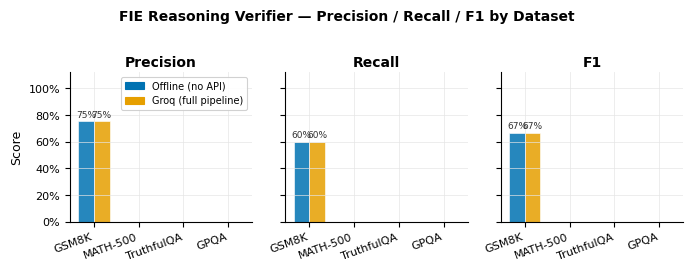

In [8]:
# ── Fig 1. Precision / Recall / F1 per dataset — Offline vs Groq ──────────────
metrics_shown = ['Precision', 'Recall', 'F1']
metric_keys   = ['precision', 'recall', 'f1']
metric_colors = [C['precision'], C['recall'], C['f1']]

ds_list   = [DS_LABELS[d] for d in DATASETS if d in offline_metrics or d in groq_metrics]
n_ds      = len(ds_list)
n_metrics = len(metrics_shown)

fig, axes = plt.subplots(1, n_metrics, figsize=(7.0, 2.6), sharey=True)
fig.suptitle('FIE Reasoning Verifier — Precision / Recall / F1 by Dataset',
             fontsize=10, fontweight='bold', y=1.02)

x     = np.arange(n_ds)
width = 0.35

for ax, metric_key, metric_label, color in zip(axes, metric_keys, metrics_shown, metric_colors):
    off_vals  = [offline_metrics.get(d, {}).get(metric_key, 0) for d in DATASETS if d in offline_metrics or d in groq_metrics]
    groq_vals = [groq_metrics.get(d,   {}).get(metric_key, 0) for d in DATASETS if d in offline_metrics or d in groq_metrics]

    b1 = ax.bar(x - width/2, off_vals,  width, color=C['offline'], alpha=0.85,
                label='Offline', edgecolor='white', linewidth=0.5)
    b2 = ax.bar(x + width/2, groq_vals, width, color=C['groq'],    alpha=0.85,
                label='Groq',    edgecolor='white', linewidth=0.5)

    # Value labels
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                    f'{h*100:.0f}%', ha='center', va='bottom', fontsize=6.5,
                    color='#333333')

    ax.set_title(metric_label, fontweight='bold', pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(ds_list, rotation=20, ha='right')
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylabel('Score' if ax == axes[0] else '')

axes[0].legend(handles=[
    mpatches.Patch(color=C['offline'], label='Offline (no API)'),
    mpatches.Patch(color=C['groq'],    label='Groq (full pipeline)'),
], loc='upper right', framealpha=0.9, fontsize=7)

fig.tight_layout()
save_fig('fig1_precision_recall_f1')
plt.show()

  Saved: fig2_recall_by_failure_type.png / .pdf


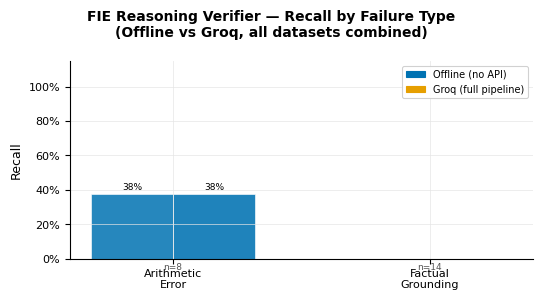

In [9]:
# ── Fig 2. Recall by failure type — stacked comparison ────────────────────────
# Collect per-type recall for both modes across all datasets combined
def per_type_recall(results):
    from collections import defaultdict
    caught = defaultdict(int)
    total  = defaultdict(int)
    for r in results:
        if r.case.is_wrong:
            total[r.case.failure_type]  += 1
            if r.predicted_failure:
                caught[r.case.failure_type] += 1
    return {
        ft: {'recall': caught[ft]/total[ft], 'caught': caught[ft], 'total': total[ft]}
        for ft in total
    }

off_type  = per_type_recall(offline_results)
groq_type = per_type_recall(groq_results)
all_types = sorted(set(list(off_type) + list(groq_type)))

TYPE_LABELS = {
    'ARITHMETIC_ERROR'      : 'Arithmetic\nError',
    'FACTUAL_GROUNDING_FAIL': 'Factual\nGrounding',
    'LOGICAL_GAP'           : 'Logical\nGap',
    'SOCRATIC_CONTRADICTION': 'Socratic\nContradiction',
}
TYPE_COLORS = {
    'ARITHMETIC_ERROR'      : C['arithmetic'],
    'FACTUAL_GROUNDING_FAIL': C['factual'],
    'LOGICAL_GAP'           : C['logical'],
    'SOCRATIC_CONTRADICTION': C['socratic'],
}

fig, ax = plt.subplots(figsize=(5.5, 3.0))
fig.suptitle('FIE Reasoning Verifier — Recall by Failure Type\n(Offline vs Groq, all datasets combined)',
             fontsize=10, fontweight='bold')

x     = np.arange(len(all_types))
width = 0.32

for i, ft in enumerate(all_types):
    off_r  = off_type.get(ft,  {}).get('recall', 0)
    groq_r = groq_type.get(ft, {}).get('recall', 0)
    off_n  = off_type.get(ft,  {}).get('total',  0)
    color  = TYPE_COLORS.get(ft, WONG['black'])

    b1 = ax.bar(i - width/2, off_r,  width, color=C['offline'], alpha=0.85,
                edgecolor='white', linewidth=0.5)
    b2 = ax.bar(i + width/2, groq_r, width, color=color,        alpha=0.88,
                edgecolor='white', linewidth=0.5)

    # Annotate with n
    ax.text(i, -0.06, f'n={off_n}', ha='center', fontsize=6.5, color='#555')

    for bar, val in [(b1, off_r), (b2, groq_r)]:
        if val > 0.02:
            ax.text(bar[0].get_x() + bar[0].get_width()/2, val + 0.015,
                    f'{val*100:.0f}%', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels([TYPE_LABELS.get(ft, ft) for ft in all_types], fontsize=8)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel('Recall')
ax.legend(handles=[
    mpatches.Patch(color=C['offline'], label='Offline (no API)'),
    mpatches.Patch(color=WONG['orange'], label='Groq (full pipeline)'),
], loc='upper right', framealpha=0.9, fontsize=7)

fig.tight_layout()
save_fig('fig2_recall_by_failure_type')
plt.show()

  Saved: fig3_confusion_tiles.png / .pdf


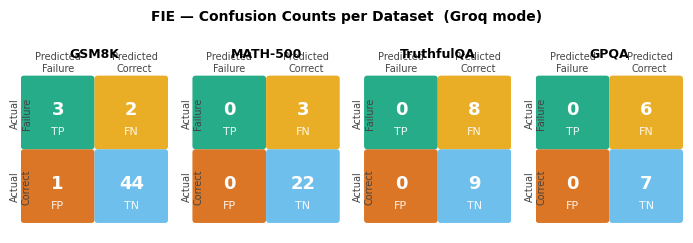

In [10]:
# ── Fig 3. Confusion matrix tiles — TP / FP / TN / FN per dataset (Groq) ──────
n_ds = len([d for d in DATASETS if d in groq_metrics])
fig, axes = plt.subplots(1, n_ds, figsize=(7.0, 2.4))
if n_ds == 1:
    axes = [axes]
fig.suptitle('FIE — Confusion Counts per Dataset  (Groq mode)',
             fontsize=10, fontweight='bold', y=1.02)

for ax, ds in zip(axes, [d for d in DATASETS if d in groq_metrics]):
    m  = groq_metrics[ds]
    tp, fp = m['tp'], m['fp']
    tn, fn = m['tn'], m['fn']

    mat    = np.array([[tp, fn], [fp, tn]])
    labels = [['TP', 'FN'], ['FP', 'TN']]
    colors = [[C['tp'], C['fn']], [C['fp'], C['tn']]]

    for r in range(2):
        for c_ in range(2):
            val = mat[r, c_]
            rect = mpatches.FancyBboxPatch(
                (c_ * 1.1, (1 - r) * 1.1), 1.0, 1.0,
                boxstyle='round,pad=0.05',
                facecolor=colors[r][c_], alpha=0.85, linewidth=0)
            ax.add_patch(rect)
            ax.text(c_ * 1.1 + 0.5, (1 - r) * 1.1 + 0.55, str(val),
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white')
            ax.text(c_ * 1.1 + 0.5, (1 - r) * 1.1 + 0.22, labels[r][c_],
                    ha='center', va='center', fontsize=8, color='white', alpha=0.9)

    ax.set_xlim(-0.05, 2.15)
    ax.set_ylim(-0.2, 2.35)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(DS_LABELS[ds], fontweight='bold', pad=4, fontsize=9)
    ax.text(0.5,  2.22, 'Predicted\nFailure',   ha='center', fontsize=7, color='#444')
    ax.text(1.65, 2.22, 'Predicted\nCorrect',   ha='center', fontsize=7, color='#444')
    ax.text(-0.05, 1.6, 'Actual\nFailure', ha='center', fontsize=7, color='#444',
            rotation=90, va='center')
    ax.text(-0.05, 0.5, 'Actual\nCorrect', ha='center', fontsize=7, color='#444',
            rotation=90, va='center')

fig.tight_layout()
save_fig('fig3_confusion_tiles')
plt.show()

  Saved: fig4_precision_recall_scatter.png / .pdf


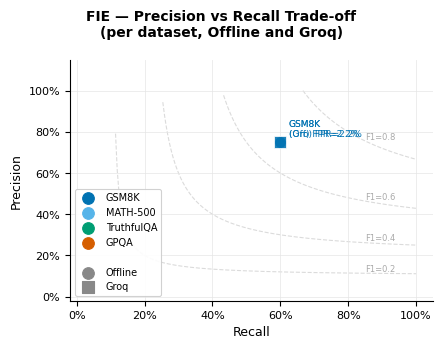

In [11]:
# ── Fig 4. Precision–Recall scatter + FPR annotations ─────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 3.5))
fig.suptitle('FIE — Precision vs Recall Trade-off\n(per dataset, Offline and Groq)',
             fontsize=10, fontweight='bold')

markers = {'Offline': 'o', 'Groq': 's'}
marker_size = 70

for ds, mode, df_src in [
    *[(d, 'Offline', offline_metrics) for d in DATASETS],
    *[(d, 'Groq',    groq_metrics)    for d in DATASETS],
]:
    m = df_src.get(ds)
    if m is None or (m['precision'] == 0 and m['recall'] == 0):
        continue
    color = C.get(ds, WONG['black'])
    ax.scatter(m['recall'], m['precision'],
               s=marker_size, color=color, alpha=0.88,
               marker=markers[mode],
               edgecolors='white', linewidths=0.6, zorder=5)
    ax.annotate(
        f"{DS_LABELS[ds]}\n({mode[:3]}) FPR={m['fpr']*100:.1f}%",
        (m['recall'], m['precision']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=6.5, color=color,
        arrowprops=dict(arrowstyle='-', color=color, lw=0.6),
    )

# Iso-F1 curves
for f1_val in [0.2, 0.4, 0.6, 0.8]:
    x_pts = np.linspace(0.01, 1.0, 200)
    y_pts = f1_val * x_pts / (2 * x_pts - f1_val)
    valid = (y_pts > 0) & (y_pts <= 1)
    ax.plot(x_pts[valid], y_pts[valid], '--', color='#CCCCCC',
            linewidth=0.8, alpha=0.7, zorder=1)
    idx = np.argmin(np.abs(x_pts[valid] - 0.85))
    ax.text(x_pts[valid][idx], y_pts[valid][idx] + 0.01,
            f'F1={f1_val:.1f}', fontsize=6, color='#AAAAAA')

ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.15)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

legend_handles = [
    plt.scatter([], [], s=marker_size, color=C[d], marker='o', label=DS_LABELS[d])
    for d in DATASETS if d in C
] + [
    mpatches.Patch(color='none', label=''),
    plt.scatter([], [], s=marker_size, color='#888', marker='o', label='Offline'),
    plt.scatter([], [], s=marker_size, color='#888', marker='s', label='Groq'),
]
ax.legend(handles=legend_handles, fontsize=7, framealpha=0.9,
          loc='lower left', ncol=1)

fig.tight_layout()
save_fig('fig4_precision_recall_scatter')
plt.show()

  Saved: fig5_latency_distribution.png / .pdf


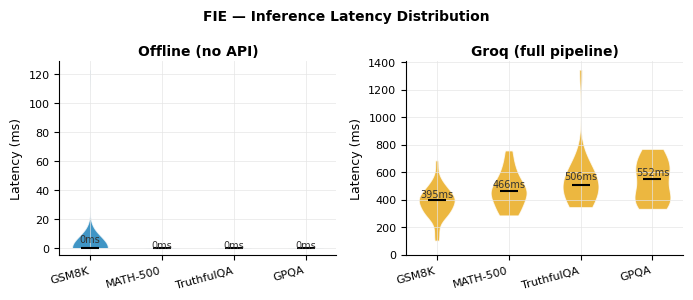

In [12]:
# ── Fig 5. Latency distribution — violin plot per dataset ──────────────────────
off_lat  = {ds: [r.latency_ms for r in offline_results if r.case.dataset == ds]
            for ds in DATASETS}
groq_lat = {ds: [r.latency_ms for r in groq_results   if r.case.dataset == ds]
            for ds in DATASETS}

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=False)
fig.suptitle('FIE — Inference Latency Distribution', fontsize=10, fontweight='bold')

for ax, lat_dict, mode_label, color in [
    (axes[0], off_lat,  'Offline (no API)', C['offline']),
    (axes[1], groq_lat, 'Groq (full pipeline)', C['groq']),
]:
    data   = [lat_dict[d] for d in DATASETS if lat_dict[d]]
    labels = [DS_LABELS[d] for d in DATASETS if lat_dict[d]]
    if not data:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
        continue

    parts = ax.violinplot(data, positions=range(len(data)),
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color(WONG['black'])
    parts['cmedians'].set_linewidth(1.5)

    # Median annotations
    for i, d in enumerate(data):
        med = np.median(d)
        ax.text(i, med + max(d)*0.03, f'{med:.0f}ms', ha='center',
                fontsize=7, color='#333')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_title(mode_label, fontweight='bold', pad=4)
    ax.set_ylabel('Latency (ms)')
    ax.set_ylim(bottom=-5)

fig.tight_layout()
save_fig('fig5_latency_distribution')
plt.show()

  Saved: fig6_confidence_distribution.png / .pdf


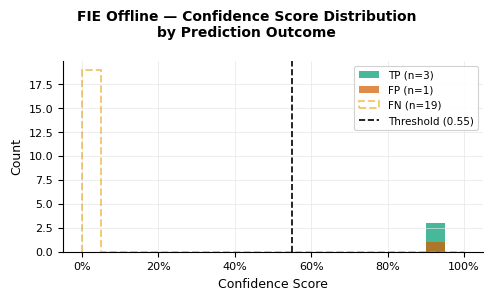

In [14]:
# ── Fig 6. Confidence distribution — correct vs incorrect predictions ──────────
off_conf_tp = [r.confidence for r in offline_results if r.case.is_wrong and r.predicted_failure]
off_conf_fp = [r.confidence for r in offline_results if not r.case.is_wrong and r.predicted_failure]
off_conf_fn = [r.confidence for r in offline_results if r.case.is_wrong and not r.predicted_failure]

fig, ax = plt.subplots(figsize=(5.0, 3.0))
fig.suptitle('FIE Offline — Confidence Score Distribution\nby Prediction Outcome',
             fontsize=10, fontweight='bold')

bins = np.linspace(0, 1, 21)
if off_conf_tp:
    ax.hist(off_conf_tp, bins=bins, color=C['tp'], alpha=0.72, label=f'TP (n={len(off_conf_tp)})')
if off_conf_fp:
    ax.hist(off_conf_fp, bins=bins, color=C['fp'], alpha=0.72, label=f'FP (n={len(off_conf_fp)})')
if off_conf_fn:
    ax.hist(off_conf_fn, bins=bins, color=C['fn'], alpha=0.55, label=f'FN (n={len(off_conf_fn)})',
            linestyle='--', histtype='step', linewidth=1.4)

ax.axvline(0.55, color=WONG['black'], lw=1.2, ls='--', label='Threshold (0.55)')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(fontsize=7.5, framealpha=0.9)

fig.tight_layout()
save_fig('fig6_confidence_distribution')
plt.show()

  Saved: fig7_radar_chart.png / .pdf


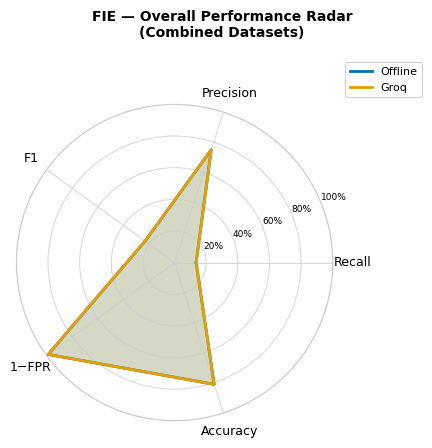

In [15]:
# ── Fig 7. Summary radar chart — Offline vs Groq across all metrics ────────────
from matplotlib.patches import FancyArrowPatch

RADAR_METRICS = ['Recall', 'Precision', 'F1', '1−FPR', 'Accuracy']
RADAR_KEYS    = ['recall', 'precision', 'f1', 'fpr',   'accuracy']
RADAR_INVERT  = [False,    False,       False, True,    False]    # FPR → higher is better inverted

def get_radar_vals(metrics_dict):
    # Use combined metrics for the radar
    m = compute_metrics(
        offline_results if metrics_dict is offline_metrics else groq_results,
        'combined'
    )
    vals = []
    for key, invert in zip(RADAR_KEYS, RADAR_INVERT):
        v = m.get(key, 0)
        vals.append(1 - v if invert else v)
    return vals

off_vals  = get_radar_vals(offline_metrics)
groq_vals = get_radar_vals(groq_metrics)

angles = np.linspace(0, 2 * np.pi, len(RADAR_METRICS), endpoint=False).tolist()
angles += angles[:1]
off_vals  += off_vals[:1]
groq_vals += groq_vals[:1]

fig, ax = plt.subplots(figsize=(4.5, 4.5), subplot_kw=dict(polar=True))
fig.suptitle('FIE — Overall Performance Radar\n(Combined Datasets)',
             fontsize=10, fontweight='bold')

ax.plot(angles, off_vals,  color=C['offline'], lw=2.0, label='Offline', zorder=3)
ax.fill(angles, off_vals,  color=C['offline'], alpha=0.18)
ax.plot(angles, groq_vals, color=C['groq'],    lw=2.0, label='Groq',    zorder=3)
ax.fill(angles, groq_vals, color=C['groq'],    alpha=0.18)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_METRICS, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%','40%','60%','80%','100%'], fontsize=6.5)
ax.grid(color='#CCCCCC', linewidth=0.7)
ax.spines['polar'].set_color('#CCCCCC')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
          fontsize=8, framealpha=0.9)

fig.tight_layout()
save_fig('fig7_radar_chart')
plt.show()

  Saved: fig8_fpr_vs_recall.png / .pdf


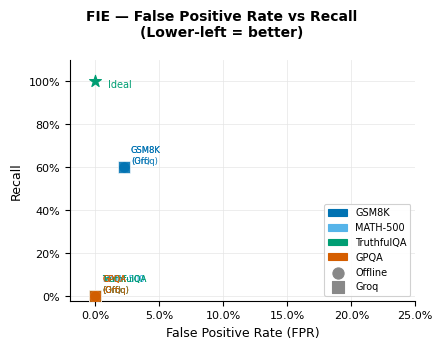

In [16]:
# ── Fig 8. FPR vs Recall — annotated trade-off plot ───────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 3.5))
fig.suptitle('FIE — False Positive Rate vs Recall\n(Lower-left = better)',
             fontsize=10, fontweight='bold')

for ds in DATASETS:
    color = C.get(ds, WONG['black'])
    for mode, m_dict, marker in [('Off', offline_metrics, 'o'), ('Groq', groq_metrics, 's')]:
        m = m_dict.get(ds)
        if m is None:
            continue
        ax.scatter(m['fpr'], m['recall'], s=65, color=color, marker=marker,
                   alpha=0.88, edgecolors='white', linewidths=0.5, zorder=5)
        ax.annotate(f"{DS_LABELS[ds]}\n({mode})",
                    (m['fpr'], m['recall']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=6, color=color)

# Ideal point
ax.scatter([0], [1], s=80, color=WONG['green'], marker='*', zorder=6, label='Ideal')
ax.text(0.01, 0.97, 'Ideal', fontsize=7, color=WONG['green'])

ax.set_xlim(-0.02, 0.25)
ax.set_ylim(-0.02, 1.10)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('Recall')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

legend_handles = [
    mpatches.Patch(color=C.get(d, '#888'), label=DS_LABELS[d])
    for d in DATASETS if d in C
] + [
    plt.scatter([], [], s=65, color='#888', marker='o', label='Offline'),
    plt.scatter([], [], s=65, color='#888', marker='s', label='Groq'),
]
ax.legend(handles=legend_handles, fontsize=7, framealpha=0.9, loc='lower right')

fig.tight_layout()
save_fig('fig8_fpr_vs_recall')
plt.show()

In [17]:
# ── Table 1. Publication-ready summary table ───────────────────────────────────
rows = []
for ds in DATASETS:
    for mode, m_dict in [('Offline', offline_metrics), ('Groq', groq_metrics)]:
        m = m_dict.get(ds)
        if m:
            rows.append({
                'Dataset'   : DS_LABELS[ds],
                'Mode'      : mode,
                'N'         : m['total_cases'],
                'Precision' : f"{m['precision']*100:.1f}%",
                'Recall'    : f"{m['recall']*100:.1f}%",
                'F1'        : f"{m['f1']*100:.1f}%",
                'FPR'       : f"{m['fpr']*100:.1f}%",
                'Accuracy'  : f"{m['accuracy']*100:.1f}%",
                'Latency'   : f"{m['avg_latency_ms']:.0f} ms",
            })

# Add combined rows
for mode, combined in [('Offline', offline_combined), ('Groq', groq_combined)]:
    rows.append({
        'Dataset'   : 'COMBINED',
        'Mode'      : mode,
        'N'         : combined['total_cases'],
        'Precision' : f"{combined['precision']*100:.1f}%",
        'Recall'    : f"{combined['recall']*100:.1f}%",
        'F1'        : f"{combined['f1']*100:.1f}%",
        'FPR'       : f"{combined['fpr']*100:.1f}%",
        'Accuracy'  : f"{combined['accuracy']*100:.1f}%",
        'Latency'   : f"{combined['avg_latency_ms']:.0f} ms",
    })

table_df = pd.DataFrame(rows)
table_path = RES_DIR / f"fie_benchmark_table_{ts}.csv"
table_df.to_csv(table_path, index=False)
print(f"Table saved: {table_path.name}\n")

# Styled display
table_df.style\
    .set_caption("Table 1. FIE Reasoning Verifier — Benchmark Results")\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#3C5488'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center')]
    }])\
    .highlight_max(subset=['Recall', 'Precision', 'F1'], color='#d4f0c8')\
    .highlight_min(subset=['FPR'],                        color='#d4f0c8')

Table saved: fie_benchmark_table_20260523_141417.csv



,Dataset,Mode,N,Precision,Recall,F1,FPR,Accuracy,Latency
0,GSM8K,Offline,50,75.0%,60.0%,66.7%,2.2%,94.0%,3 ms
1,GSM8K,Groq,50,75.0%,60.0%,66.7%,2.2%,94.0%,384 ms
2,MATH-500,Offline,25,0.0%,0.0%,0.0%,0.0%,88.0%,0 ms
3,MATH-500,Groq,25,0.0%,0.0%,0.0%,0.0%,88.0%,472 ms
4,TruthfulQA,Offline,17,0.0%,0.0%,0.0%,0.0%,52.9%,0 ms
5,TruthfulQA,Groq,17,0.0%,0.0%,0.0%,0.0%,52.9%,548 ms
6,GPQA,Offline,13,0.0%,0.0%,0.0%,0.0%,53.8%,0 ms
7,GPQA,Groq,13,0.0%,0.0%,0.0%,0.0%,53.8%,540 ms
8,COMBINED,Offline,105,75.0%,13.6%,23.1%,1.2%,81.0%,1 ms
9,COMBINED,Groq,105,75.0%,13.6%,23.1%,1.2%,81.0%,451 ms


In [18]:
# ── Final summary ──────────────────────────────────────────────────────────────
print("=" * 60)
print("FIE REASONING BENCHMARK — FINAL SUMMARY")
print("=" * 60)
print(f"\nOffline mode (no API, heuristic-only):")
print(f"  Precision : {offline_combined['precision']*100:.1f}%")
print(f"  Recall    : {offline_combined['recall']*100:.1f}%")
print(f"  F1        : {offline_combined['f1']*100:.1f}%")
print(f"  FPR       : {offline_combined['fpr']*100:.1f}%")
print(f"  Latency   : {offline_combined['avg_latency_ms']:.0f} ms avg")
print(f"\nGroq mode (full pipeline):")
print(f"  Precision : {groq_combined['precision']*100:.1f}%")
print(f"  Recall    : {groq_combined['recall']*100:.1f}%")
print(f"  F1        : {groq_combined['f1']*100:.1f}%")
print(f"  FPR       : {groq_combined['fpr']*100:.1f}%")
print(f"  Latency   : {groq_combined['avg_latency_ms']:.0f} ms avg")
print(f"\nFigures saved to  : {FIG_DIR.resolve()}")
print(f"Results saved to  : {RES_DIR.resolve()}")
print(f"\nFigures generated :")
for p in sorted(FIG_DIR.glob('*.png')):
    print(f"  {p.name}")

FIE REASONING BENCHMARK — FINAL SUMMARY

Offline mode (no API, heuristic-only):
  Precision : 75.0%
  Recall    : 13.6%
  F1        : 23.1%
  FPR       : 1.2%
  Latency   : 1 ms avg

Groq mode (full pipeline):
  Precision : 75.0%
  Recall    : 13.6%
  F1        : 23.1%
  FPR       : 1.2%
  Latency   : 451 ms avg

Figures saved to  : C:\Users\ASUS\Desktop\Failure_Intelligence_System\notebooks\benchmark_figures
Results saved to  : C:\Users\ASUS\Desktop\Failure_Intelligence_System\notebooks\benchmark_results

Figures generated :
  fig1_precision_recall_f1.png
  fig2_recall_by_failure_type.png
  fig3_confusion_tiles.png
  fig4_precision_recall_scatter.png
  fig5_latency_distribution.png
  fig6_confidence_distribution.png
  fig7_radar_chart.png
  fig8_fpr_vs_recall.png


---

## Appendix — LLM-vs-FIE on GPQA
### Can FIE Detect Expert-Level Reasoning Failures?

**GPQA** (Graduate-Level Google-Proof Q&A) — 448 questions written by PhD scientists.  
Published zero-shot accuracy benchmarks:

| Model | GPQA Accuracy |
|-------|---------------|
| Human (non-expert) | ~34% |
| GPT-4 | ~39% |
| Claude 3 Opus | ~50% |
| GPT-4o | ~53% |
| Human (expert) | ~81% |

Here we run an LLM as the **system under test**, then use **FIE's reasoning verifier** as the failure detector.  
**Key question: when the LLM is wrong on GPQA, does FIE catch it?**

> Set `SKIP_LLM_EVAL = True` to reload from saved JSON instead of re-running the LLM.

In [19]:
# ── Appendix-0. LLM-under-test configuration ──────────────────────────────────
# Default: Groq  (GROQ_API_KEY already in .env)
# To use OpenAI: set LLM_PROVIDER = "openai" and add OPENAI_API_KEY to .env
#
# GPQA_LIMIT: questions sent to the LLM  (costs API credits)
#   50  — quick test  (~2 min)     200 — paper-quality  (~8 min)

import os, random, re, time, json
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

load_dotenv(dotenv_path=Path("../.env"))

LLM_PROVIDER   = "groq"                     # "groq" | "openai"
GROQ_MODEL     = "llama-3.3-70b-versatile"  # or "mixtral-8x7b-32768"
OPENAI_MODEL   = "gpt-4o"                   # or "gpt-4-turbo"
GPQA_LIMIT     = 50                         # increase to 200+ for full results
GPQA_SUBSET    = "gpqa_main"               # "gpqa_main" | "gpqa_diamond"
SKIP_LLM_EVAL  = False                      # True = reload from saved JSON

if LLM_PROVIDER == "groq":
    assert os.getenv("GROQ_API_KEY"), "GROQ_API_KEY not found in .env"
    print(f"Provider : Groq  ({GROQ_MODEL})")
elif LLM_PROVIDER == "openai":
    assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found in .env"
    print(f"Provider : OpenAI  ({OPENAI_MODEL})")

print(f"GPQA     : {GPQA_SUBSET}  |  limit={GPQA_LIMIT}")
print(f"Skip LLM : {SKIP_LLM_EVAL}")


Provider : Groq  (llama-3.3-70b-versatile)
GPQA     : gpqa_main  |  limit=50
Skip LLM : False


In [ ]:
# ── Appendix-1. Run LLM on GPQA (4-choice MCQ + chain-of-thought) ─────────────

@dataclass
class GPQALLMResult:
    question_id:   int
    question:      str
    correct_ans:   str
    llm_answer:    str
    llm_reasoning: str
    llm_correct:   bool
    domain:        str
    subdomain:     str
    latency_ms:    float
    choices:       list
    correct_label: str


def _call_groq(prompt, model):
    from groq import Groq
    client = Groq(api_key=os.getenv("GROQ_API_KEY"))
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model, messages=[{"role": "user", "content": prompt}],
        max_tokens=600, temperature=0.0,
    )
    return resp.choices[0].message.content.strip(), (time.time() - t0) * 1000


def _call_openai(prompt, model):
    import openai
    client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    t0 = time.time()
    resp = client.chat.completions.create(
        model=model, messages=[{"role": "user", "content": prompt}],
        max_tokens=600, temperature=0.0,
    )
    return resp.choices[0].message.content.strip(), (time.time() - t0) * 1000


def evaluate_gpqa_with_llm(limit, subset, provider, groq_model, openai_model):
    import warnings; warnings.filterwarnings("ignore")
    from datasets import load_dataset
    ds = load_dataset("Idavidrein/gpqa", subset, split="train")
    results = []
    labels  = ["A", "B", "C", "D"]
    for i, row in enumerate(ds):
        if i >= limit:
            break
        question    = (row.get("Question") or "").strip()
        correct_ans = (row.get("Correct Answer") or "").strip()
        wrong1      = (row.get("Incorrect Answer 1") or "").strip()
        wrong2      = (row.get("Incorrect Answer 2") or "").strip()
        wrong3      = (row.get("Incorrect Answer 3") or "").strip()
        domain      = (row.get("High-level domain") or "Science").strip()
        subdomain   = (row.get("Subdomain") or domain).strip()
        if not question or not correct_ans:
            continue
        choices = [c for c in [correct_ans, wrong1, wrong2, wrong3] if c]
        random.seed(i)
        random.shuffle(choices)
        correct_label = labels[choices.index(correct_ans)] if correct_ans in choices else "A"
        choice_text   = "\n".join(f"({lab}) {ch}" for lab, ch in zip(labels, choices))
        prompt = (
            "You are an expert scientist. Answer the multiple-choice question "
            "with step-by-step reasoning.\n\n"
            f"Question: {question}\n\n{choice_text}\n\n"
            "Think step by step, then state your final answer as exactly one letter on the last line.\n"
            "Format: Answer: <letter>"
        )
        try:
            if provider == "groq":
                response, lat = _call_groq(prompt, groq_model)
            else:
                response, lat = _call_openai(prompt, openai_model)
        except Exception as e:
            print(f"  [{i}] API error: {e}")
            continue
        m = re.search(r"Answer:\s*([A-D])", response, re.IGNORECASE)
        chosen_label = m.group(1).upper() if m else (re.findall(r"\b([A-D])\b", response) or ["A"])[-1]
        label_idx   = labels.index(chosen_label) if chosen_label in labels else 0
        chosen_ans  = choices[label_idx] if label_idx < len(choices) else choices[0]
        llm_correct = chosen_label == correct_label
        status      = "OK  " if llm_correct else "FAIL"
        print(f"  [{i+1:3d}/{limit}] {domain[:22]:22s} | {status} | {lat:.0f}ms")
        results.append(GPQALLMResult(
            question_id=i, question=question, correct_ans=correct_ans,
            llm_answer=chosen_ans, llm_reasoning=response, llm_correct=llm_correct,
            domain=domain, subdomain=subdomain, latency_ms=lat,
            choices=choices, correct_label=correct_label,
        ))
    acc = sum(r.llm_correct for r in results) / len(results) if results else 0
    print(f"\nLLM accuracy on {subset}: {acc*100:.1f}%  ({sum(r.llm_correct for r in results)}/{len(results)})")
    return results


if SKIP_LLM_EVAL:
    saved = sorted(RES_DIR.glob("gpqa_llm_*.json"))
    if saved:
        with open(saved[-1]) as f:
            _d = json.load(f)
        print(f"Loaded: {saved[-1].name}  (n={_d['n']})")
        print(f"LLM accuracy: {_d['llm_accuracy']*100:.1f}%")
        llm_results = []  # raw objects not available; FIE cell will skip
    else:
        print("No saved results — set SKIP_LLM_EVAL=False to run.")
        llm_results = []
else:
    model_label = GROQ_MODEL if LLM_PROVIDER == "groq" else OPENAI_MODEL
    print(f"Running {GPQA_LIMIT} GPQA questions through {LLM_PROVIDER.upper()} ({model_label})...")
    llm_results = evaluate_gpqa_with_llm(
        limit=GPQA_LIMIT, subset=GPQA_SUBSET,
        provider=LLM_PROVIDER, groq_model=GROQ_MODEL, openai_model=OPENAI_MODEL,
    )


Running 50 GPQA questions through GROQ (llama-3.3-70b-versatile)...
  [  1/50] Biology                | FAIL | 2608ms


In [ ]:
# ── Appendix-2. FIE Reasoning Verifier on LLM Outputs ─────────────────────────
# Ground truth: did the LLM get the GPQA question right?
# FIE target:   flag cases where LLM reasoning is wrong.

from engine.reasoning.reasoning_verifier import verify_reasoning


@dataclass
class GPQAFIEResult:
    llm:            GPQALLMResult
    fie_detected:   bool
    fie_type:       str
    fie_confidence: float
    fie_latency_ms: float
    is_tp: bool   # LLM wrong AND FIE flagged
    is_fp: bool   # LLM correct AND FIE flagged  (false alarm)
    is_tn: bool   # LLM correct AND FIE quiet
    is_fn: bool   # LLM wrong AND FIE missed


fie_results: list = []

if not llm_results:
    print("No LLM results — run Appendix-1 first (or set SKIP_LLM_EVAL=False).")
else:
    print(f"Running FIE on {len(llm_results)} GPQA LLM outputs (use_groq=True)...")
    for idx, r in enumerate(llm_results):
        t0 = time.time()
        vr = verify_reasoning(
            question       = r.question,
            primary_answer = r.llm_reasoning,
            shadow_outputs = [],
            use_groq       = True,
        )
        lat      = (time.time() - t0) * 1000
        detected = vr.failure_detected and vr.confidence >= 0.55
        wrong    = not r.llm_correct
        mark     = ("TP" if (wrong and detected) else
                    "FN" if wrong else
                    "FP" if detected else "TN")
        print(
            f"  [{idx+1:3d}/{len(llm_results)}] "
            f"{r.domain[:20]:20s} "
            f"LLM={'WRONG' if wrong else 'OK  '} "
            f"FIE={mark} conf={vr.confidence:.2f}"
        )
        fie_results.append(GPQAFIEResult(
            llm=r, fie_detected=detected, fie_type=vr.failure_type,
            fie_confidence=vr.confidence, fie_latency_ms=lat,
            is_tp=wrong and detected,     is_fp=(not wrong) and detected,
            is_tn=(not wrong) and (not detected), is_fn=wrong and (not detected),
        ))

    tp = sum(r.is_tp for r in fie_results); fp = sum(r.is_fp for r in fie_results)
    tn = sum(r.is_tn for r in fie_results); fn = sum(r.is_fn for r in fie_results)
    n_ok    = sum(r.llm.llm_correct for r in fie_results)
    n_wrong = len(fie_results) - n_ok
    prec    = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_s    = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0
    fpr     = fp / (fp + tn) if (fp + tn) > 0 else 0

    _payload = {
        "provider": LLM_PROVIDER,
        "model": GROQ_MODEL if LLM_PROVIDER == "groq" else OPENAI_MODEL,
        "gpqa_subset": GPQA_SUBSET, "n": len(fie_results),
        "llm_accuracy": n_ok / len(fie_results),
        "fie_precision": prec, "fie_recall": recall, "fie_f1": f1_s, "fie_fpr": fpr,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "cases": [
            {"qid": r.llm.question_id, "domain": r.llm.domain,
             "llm_correct": r.llm.llm_correct, "fie_detected": r.fie_detected,
             "fie_type": r.fie_type, "fie_conf": round(r.fie_confidence, 4),
             "is_tp": r.is_tp, "is_fp": r.is_fp, "is_tn": r.is_tn, "is_fn": r.is_fn}
            for r in fie_results
        ],
    }
    _sp = RES_DIR / f"gpqa_llm_{LLM_PROVIDER}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(_sp, "w") as f:
        json.dump(_payload, f, indent=2)

    print(f"\n{'='*55}")
    print(f"FIE Detection on {LLM_PROVIDER.upper()} GPQA Failures")
    print(f"{'='*55}")
    print(f"  LLM accuracy : {n_ok/len(fie_results)*100:.1f}%  ({n_ok}/{len(fie_results)})")
    print(f"  LLM errors   : {n_wrong}  <- FIE target")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(f"  FIE Precision: {prec*100:.1f}%")
    print(f"  FIE Recall   : {recall*100:.1f}%  (of LLM errors caught by FIE)")
    print(f"  FIE F1       : {f1_s*100:.1f}%")
    print(f"  FIE FPR      : {fpr*100:.1f}%  (false alarms on correct LLM answers)")
    print(f"  Saved        : {_sp.name}")


In [ ]:
# ── Fig 9. LLM Accuracy vs FIE Detection Rate per Domain ──────────────────────

if not fie_results:
    print("No results — run Appendix cells first.")
else:
    from collections import defaultdict

    domain_stats = defaultdict(lambda: {"total": 0, "llm_ok": 0, "llm_wrong": 0, "fie_tp": 0})
    for r in fie_results:
        d = r.llm.domain
        domain_stats[d]["total"] += 1
        if r.llm.llm_correct:
            domain_stats[d]["llm_ok"] += 1
        else:
            domain_stats[d]["llm_wrong"] += 1
        if r.is_tp:
            domain_stats[d]["fie_tp"] += 1

    domains      = sorted(domain_stats, key=lambda d: -domain_stats[d]["total"])
    llm_accs     = [domain_stats[d]["llm_ok"] / domain_stats[d]["total"] for d in domains]
    fie_recalls  = [
        domain_stats[d]["fie_tp"] / domain_stats[d]["llm_wrong"]
        if domain_stats[d]["llm_wrong"] > 0 else 0
        for d in domains
    ]
    ns           = [domain_stats[d]["total"] for d in domains]
    model_label  = GROQ_MODEL if LLM_PROVIDER == "groq" else OPENAI_MODEL

    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    fig.suptitle(
        f"GPQA — {LLM_PROVIDER.upper()} Accuracy vs FIE Failure Detection by Domain\n"
        f"(Model: {model_label}, n={len(fie_results)})",
        fontsize=10, fontweight="bold",
    )
    x = np.arange(len(domains)); width = 0.38
    b1 = ax.bar(x - width/2, llm_accs,   width, color=C["sky"],      alpha=0.85,
                label="LLM Accuracy", edgecolor="white", linewidth=0.5)
    b2 = ax.bar(x + width/2, fie_recalls, width, color=C["vermilion"], alpha=0.85,
                label="FIE Recall on LLM Errors", edgecolor="white", linewidth=0.5)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                    f"{h*100:.0f}%", ha="center", va="bottom", fontsize=6.5)
    for i, (d, n) in enumerate(zip(domains, ns)):
        ax.text(i, -0.08, f"n={n}", ha="center", fontsize=6.5, color="#555")

    # Reference line: GPT-4 published GPQA accuracy (~39%)
    ax.axhline(0.39, color=WONG["orange"], lw=1.1, ls="--", alpha=0.75)
    ax.text(len(domains) - 0.5, 0.41, "GPT-4 avg (~39%)",
            fontsize=6.5, color=WONG["orange"], ha="right")

    ax.set_xticks(x)
    ax.set_xticklabels(domains, rotation=18, ha="right", fontsize=8)
    ax.set_ylim(0, 1.18)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylabel("Rate")
    ax.legend(handles=[
        mpatches.Patch(color=C["sky"],       label=f"{LLM_PROVIDER.upper()} Accuracy on GPQA"),
        mpatches.Patch(color=C["vermilion"], label="FIE Recall on LLM Failures"),
    ], loc="upper right", fontsize=7.5, framealpha=0.9)
    fig.tight_layout()
    save_fig("fig9_gpqa_domain_breakdown")
    plt.show()


In [ ]:
# ── Fig 10. FIE Confusion on GPQA + Failure-type Pie + Table 2 ────────────────

if not fie_results:
    print("No results — run Appendix cells first.")
else:
    from collections import Counter

    tp = sum(r.is_tp for r in fie_results); fp = sum(r.is_fp for r in fie_results)
    tn = sum(r.is_tn for r in fie_results); fn = sum(r.is_fn for r in fie_results)
    n_all    = len(fie_results)
    llm_acc  = sum(r.llm.llm_correct for r in fie_results) / n_all
    fie_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    fie_rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    fie_f1   = 2 * fie_prec * fie_rec / (fie_prec + fie_rec) if (fie_prec + fie_rec) > 0 else 0
    fie_fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0

    model_label = GROQ_MODEL if LLM_PROVIDER == "groq" else OPENAI_MODEL
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3.4))
    fig.suptitle(
        f"FIE as Failure Detector for {LLM_PROVIDER.upper()} ({model_label}) on GPQA\n"
        f"LLM accuracy: {llm_acc*100:.1f}%   FIE recall: {fie_rec*100:.1f}%   FPR: {fie_fpr*100:.1f}%",
        fontsize=10, fontweight="bold",
    )

    # Left: confusion matrix
    mat    = [[tp, fn], [fp, tn]]
    clbls  = [["TP", "FN"], ["FP", "TN"]]
    clrs   = [[C["tp"], C["fn"]], [C["fp"], C["tn"]]]
    for r in range(2):
        for c_ in range(2):
            rect = mpatches.FancyBboxPatch(
                (c_ * 1.15, (1 - r) * 1.15), 1.05, 1.05,
                boxstyle="round,pad=0.04", facecolor=clrs[r][c_], alpha=0.88, linewidth=0)
            ax1.add_patch(rect)
            ax1.text(c_ * 1.15 + 0.525, (1 - r) * 1.15 + 0.62, str(mat[r][c_]),
                     ha="center", va="center", fontsize=20, fontweight="bold", color="white")
            ax1.text(c_ * 1.15 + 0.525, (1 - r) * 1.15 + 0.22, clbls[r][c_],
                     ha="center", va="center", fontsize=9, color="white", alpha=0.9)
    ax1.set_xlim(-0.15, 2.35); ax1.set_ylim(-0.3, 2.48)
    ax1.set_aspect("equal"); ax1.axis("off")
    ax1.set_title("FIE Confusion Matrix\n(ground truth = LLM error on GPQA)",
                  fontweight="bold", pad=8, fontsize=9)
    ax1.text(0.525,  2.35, "FIE: Failure", ha="center", fontsize=8, color="#333")
    ax1.text(1.675,  2.35, "FIE: Correct", ha="center", fontsize=8, color="#333")
    ax1.text(-0.10,  1.70, "LLM\nWrong",  ha="center", fontsize=8, color="#333",
             rotation=90, va="center")
    ax1.text(-0.10,  0.60, "LLM\nCorrect", ha="center", fontsize=8, color="#333",
             rotation=90, va="center")

    # Right: failure-type breakdown for caught LLM errors
    TYPE_COLOR = {
        "ARITHMETIC_ERROR": "#0072B2", "FACTUAL_GROUNDING_FAIL": "#D55E00",
        "LOGICAL_GAP": "#009E73",      "SOCRATIC_CONTRADICTION": "#CC79A7",
        "NO_FAILURE_DETECTED": "#000000",
    }
    TYPE_SHORT = {
        "ARITHMETIC_ERROR": "Arithmetic", "FACTUAL_GROUNDING_FAIL": "Factual",
        "LOGICAL_GAP": "Logical",         "SOCRATIC_CONTRADICTION": "Socratic",
        "NO_FAILURE_DETECTED": "None",
    }
    caught = [r for r in fie_results if not r.llm.llm_correct and r.fie_detected]
    if caught:
        cnt  = Counter(r.fie_type for r in caught)
        keys = list(cnt.keys()); vals_p = [cnt[k] for k in keys]
        wedges, texts, autotexts = ax2.pie(
            vals_p, labels=[TYPE_SHORT.get(k, k) for k in keys],
            autopct="%1.0f%%", colors=[TYPE_COLOR.get(k, "#888") for k in keys],
            startangle=140, pctdistance=0.75, labeldistance=1.08,
            textprops={"fontsize": 8}, wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
        )
        for at in autotexts:
            at.set_fontsize(8); at.set_color("white")
        ax2.set_title(f"FIE Failure Types\non Caught LLM Errors (n={sum(vals_p)})",
                      fontweight="bold", pad=8, fontsize=9)
    else:
        ax2.text(0.5, 0.5, "No detections yet\n(re-run with use_groq=True)",
                 ha="center", transform=ax2.transAxes, fontsize=9)
        ax2.axis("off")

    fig.tight_layout()
    save_fig("fig10_gpqa_fie_confusion")
    plt.show()

    # Table 2
    print(f"\n{'='*55}")
    print(f"Table 2. FIE vs {LLM_PROVIDER.upper()} on GPQA ({GPQA_SUBSET})")
    print(f"{'='*55}")
    t2_df = pd.DataFrame([
        {"Metric": "LLM Accuracy",            "Value": f"{llm_acc*100:.1f}%"},
        {"Metric": "LLM Errors (FIE target)", "Value": str(tp + fn)},
        {"Metric": "FIE TP / FP / TN / FN",  "Value": f"{tp} / {fp} / {tn} / {fn}"},
        {"Metric": "FIE Precision",            "Value": f"{fie_prec*100:.1f}%"},
        {"Metric": "FIE Recall on LLM errors", "Value": f"{fie_rec*100:.1f}%"},
        {"Metric": "FIE F1",                   "Value": f"{fie_f1*100:.1f}%"},
        {"Metric": "FIE FPR (false alarms)",   "Value": f"{fie_fpr*100:.1f}%"},
    ])
    _tp = RES_DIR / f"gpqa_fie_table2_{datetime.now().strftime('%Y%m%d')}.csv"
    t2_df.to_csv(_tp, index=False)
    display(t2_df.style.set_caption(
        f"Table 2. FIE Failure Detection on {LLM_PROVIDER.upper()} GPQA Outputs"
    ).set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#3C5488"), ("color", "white"), ("font-weight", "bold")],
    }]))
    print(f"Saved: {_tp.name}")
